(2400, 306) (600, 306)
Canonical_AutoEncoder(
    # attributes
    input_size = 306
    hidden_layers = [306, 306, 306]
    n_latents = 8
)
INITIALIZATION COMPLETE
(3000, 102, 3)
(3000, 306)
Perturbed Latents Shape: (600, 8)


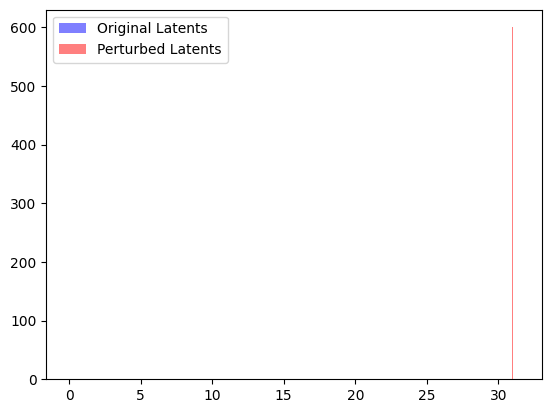

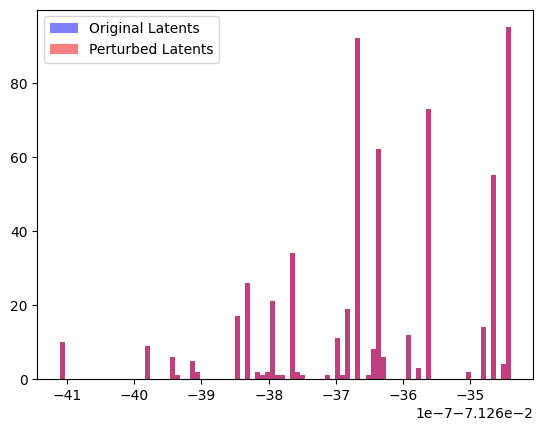

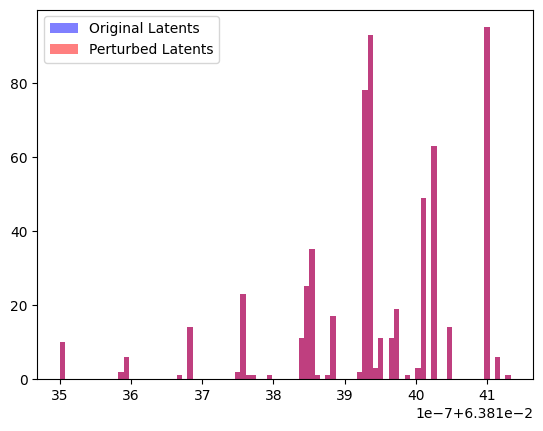

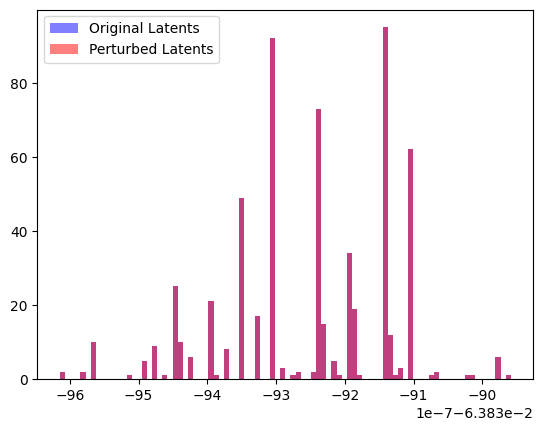

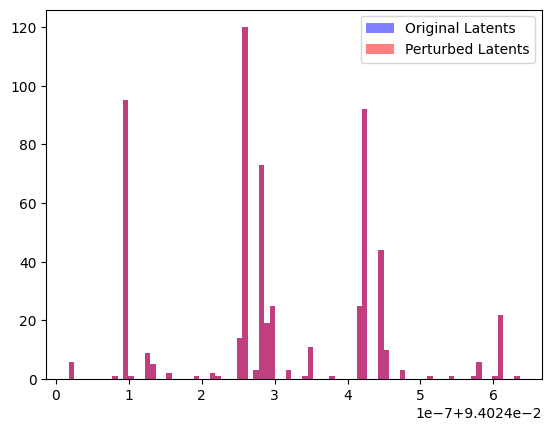

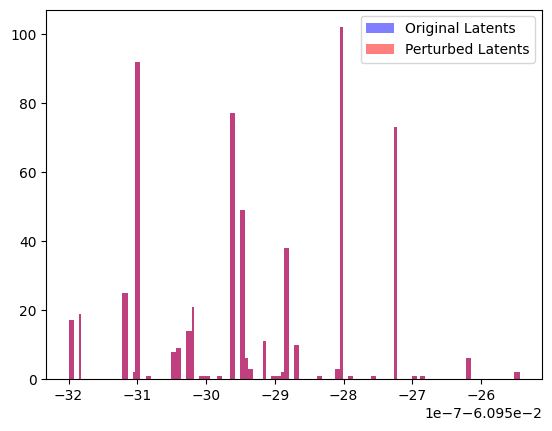

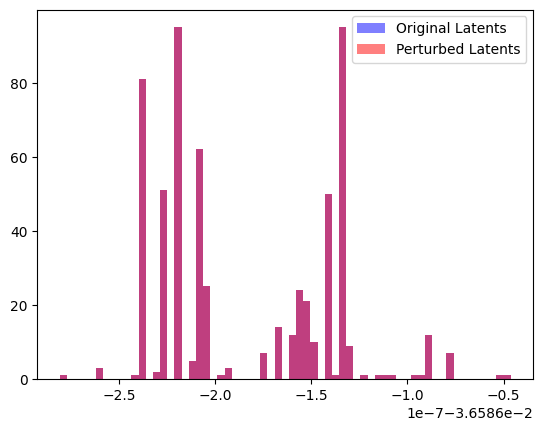

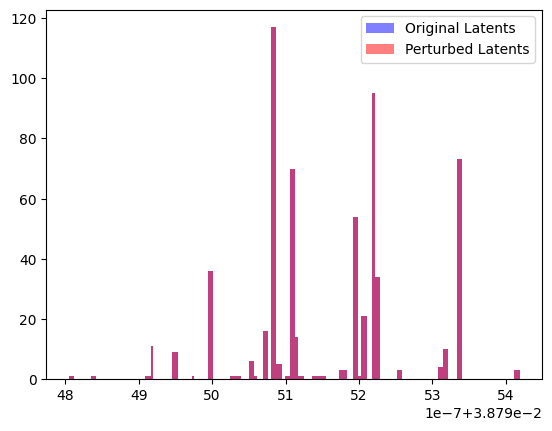

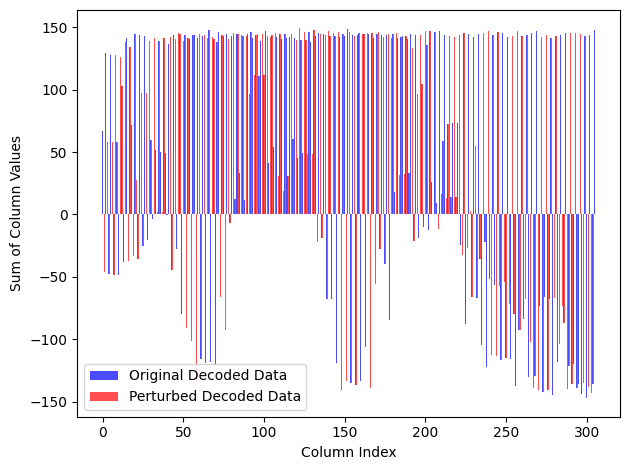

Different indices: [[  0   0]
 [  0   1]
 [  0   2]
 ...
 [599 303]
 [599 304]
 [599 305]]


In [1]:
import Canonical_AutoEncoder_Experiment
import sys
import jax
import mdtraj as md
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

# Configure JAX to use 64-bit precision
jax.config.update("jax_enable_x64", True)

# JSON configuration file path
json_fn = "/media/volume/sdb/Timooo/Auto_Encoding_FE/AE_TEST_SMALL_08_3.json"

# Initialize the experiment
experiment = Canonical_AutoEncoder_Experiment.NN_Experiment(json_fn)

# Loading the model checkpoint
ckpt_fn = "model_ckpt_005000.pkl"
experiment.load_model_from_ckpt(ckpt_fn)

# Save testing data as a trajectory
experiment.write_traj("test_data", experiment.test_data)

# Load simulation data
c = md.load('/media/volume/sdb/Timooo/Auto_Encoding_FE/Simulation/small_test.dcd', top='/media/volume/sdb/Timooo/Auto_Encoding_FE/Simulation/ala_deca_peptide.prmtop')
coords = jnp.array(c.superpose(c).xyz)
print(coords.shape)

# Flatten the dimensions
coords = coords.reshape(coords.shape[0], -1)
print(coords.shape)

# Encode the test data, obtaining both decoded and latent representations
recon = experiment.state.apply_fn({'params': experiment.state.params}, experiment.test_data)
decoded_data = recon[0]
original_latents = recon[1]

# Perturb Latent Representations
perturbed_latents = jnp.array(original_latents)  # Copy original latents
perturbed_latents = perturbed_latents.at[:, 0].add(31)  # Perturb the first column

# Print the shape of the perturbed latents
print("Perturbed Latents Shape:", perturbed_latents.shape)

# Visualize original latents and perturbed latents
for i in range(8):
    _ = plt.hist(original_latents[:, i], bins=100, color='blue', alpha=0.5, label='Original Latents')
    _ = plt.hist(perturbed_latents[:, i], bins=100, color='red', alpha=0.5, label='Perturbed Latents')
    plt.legend()
    plt.show()

# Plot column sums for original decoded data and perturbed decoded data
def plot_column_sums(original_data, perturbed_data):
    if original_data.shape != perturbed_data.shape:
        raise ValueError("Shape mismatch between original_data and perturbed_data")

    columns = np.arange(original_data.shape[1])
    original_sums = np.sum(original_data, axis=0)
    perturbed_sums = np.sum(perturbed_data, axis=0)

    plt.bar(columns - 0.2, original_sums, width=0.4, color='blue', alpha=0.7, label='Original Decoded Data')
    plt.bar(columns + 0.2, perturbed_sums, width=0.4, color='red', alpha=0.7, label='Perturbed Decoded Data')

    plt.xlabel('Column Index')
    plt.ylabel('Sum of Column Values')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Decode the perturbed latent representations
perturbed_decoded = experiment.model.apply({'params': experiment.state.params}, perturbed_latents, method=experiment.model.decode)

# Plot column sums for original decoded data and perturbed decoded data
plot_column_sums(decoded_data, perturbed_decoded)

# Compare the original decoded data and perturbed decoded data
def compare_arrays(arr1, arr2):
    diff_cells = jnp.argwhere(arr1 != arr2)
    return diff_cells

diff_cells = compare_arrays(decoded_data, perturbed_decoded)
print(f"Different indices: {diff_cells}")

# Write perturbed decoded data to a DCD file
def write_dcd(filename, data):
    with md.formats.DCDTrajectoryFile(filename, 'w') as f:
        # Reshape and save data (assuming angstrom as unit)
        f.write(data.reshape(data.shape[0], -1, 3) * 10)  # Convert to angstrom

# Save perturbed decoded data as a DCD file
write_dcd("perturbed_decoded.dcd", perturbed_decoded)

# Save perturbed decoded data as a PDB file
def write_pdb(filename, data, topology):
    traj = md.Trajectory(data.reshape(data.shape[0], -1, 3), topology=topology)
    traj.save_pdb(filename)

# Save perturbed decoded data as a PDB file
write_pdb("perturbed_decoded.pdb", perturbed_decoded, c.topology)

# Visualize "perturbed_decoded.dcd" and "perturbed_decoded.pdb" in Chimera or other molecular visualization tools
# You can open Chimera and load both the DCD and PDB files for visualization.



In [1]:
import matplotlib.pyplot as plt

# Define the number of bins for the histograms
num_bins = 50

# Function to create histograms for latent dimensions
def create_latent_histograms(original_latents, perturbed_latents):
    num_latent_dimensions = original_latents.shape[1]

    for i in range(num_latent_dimensions):
        plt.figure(figsize=(8, 4))

        # Original Latents Histogram
        plt.subplot(1, 2, 1)
        plt.hist(original_latents[:, i], bins=num_bins, color='blue', alpha=0.5)
        plt.xlabel(f'Latent Dimension {i+1}')
        plt.ylabel('Frequency')
        plt.title('Original Latents')

        # Perturbed Latents Histogram
        plt.subplot(1, 2, 2)
        plt.hist(perturbed_latents[:, i], bins=num_bins, color='red', alpha=0.5)
        plt.xlabel(f'Latent Dimension {i+1}')
        plt.ylabel('Frequency')
        plt.title('Perturbed Latents')

        plt.tight_layout()
        plt.show()

# Create histograms for latent dimensions
create_latent_histograms(original_latents, perturbed_latents)


NameError: name 'original_latents' is not defined